# Credit Risk Intelligence System for Loan Default Prediction

## Problem Statement

Financial institutions must evaluate loan applications carefully to minimize the risk of borrower default. Approving high-risk applicants can result in financial losses, while rejecting too many applications may limit potential revenue.

This project analyzes loan applicant data and develops a machine learning model to predict the probability of loan default. The objective is to identify key risk indicators and support data-driven lending decisions.

Key objectives:
- Analyze financial characteristics of loan applicants
- Identify factors associated with loan default
- Build a predictive model for default risk
- Explore borrower risk patterns using data visualization

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("/kaggle/input/datasets/sanjana1317/home-credit-default-risk-dataset/application_train.csv")

In [4]:
df.shape

(307511, 122)

In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [7]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [9]:
selected_features = [
'TARGET',
'CNT_CHILDREN',
'AMT_INCOME_TOTAL',
'AMT_CREDIT',
'AMT_ANNUITY',
'AMT_GOODS_PRICE',
'DAYS_BIRTH',
'DAYS_EMPLOYED',
'CNT_FAM_MEMBERS',
'REGION_POPULATION_RELATIVE',
'EXT_SOURCE_1',
'EXT_SOURCE_2',
'EXT_SOURCE_3',
'AMT_REQ_CREDIT_BUREAU_YEAR'
]

df = df[selected_features]

In [10]:
df.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,REGION_POPULATION_RELATIVE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR
0,1,0,202500.0,406597.5,24700.5,351000.0,-9461,-637,1.0,0.018801,0.083037,0.262949,0.139376,1.0
1,0,0,270000.0,1293502.5,35698.5,1129500.0,-16765,-1188,2.0,0.003541,0.311267,0.622246,NaN,0.0
2,0,0,67500.0,135000.0,6750.0,135000.0,-19046,-225,1.0,0.010032,NaN,0.555912,0.729567,0.0
3,0,0,135000.0,312682.5,29686.5,297000.0,-19005,-3039,2.0,0.008019,NaN,0.650442,NaN,NaN
4,0,0,121500.0,513000.0,21865.5,513000.0,-19932,-3038,1.0,0.028663,NaN,0.322738,NaN,0.0


In [12]:
df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365

df['EMPLOYMENT_YEARS'] = abs(df['DAYS_EMPLOYED']) / 365

df['DTI'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

df['LOAN_BURDEN'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

df.drop(['DAYS_BIRTH','DAYS_EMPLOYED'], axis=1, inplace=True)

/tmp/ipykernel_55/1205475072.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)


In [13]:
df.head()

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_FAM_MEMBERS,REGION_POPULATION_RELATIVE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,DTI,LOAN_BURDEN,AGE_YEARS,EMPLOYMENT_YEARS
0,1,0,202500.0,406597.5,24700.5,351000.0,1.0,0.018801,0.083037,0.262949,0.139376,1.0,2.007889,0.121978,25.920548,1.745205
1,0,0,270000.0,1293502.5,35698.5,1129500.0,2.0,0.003541,0.311267,0.622246,NaN,0.0,4.790750,0.132217,45.931507,3.254795
2,0,0,67500.0,135000.0,6750.0,135000.0,1.0,0.010032,NaN,0.555912,0.729567,0.0,2.000000,0.100000,52.180822,0.616438
3,0,0,135000.0,312682.5,29686.5,297000.0,2.0,0.008019,NaN,0.650442,NaN,NaN,2.316167,0.219900,52.068493,8.326027
4,0,0,121500.0,513000.0,21865.5,513000.0,1.0,0.028663,NaN,0.322738,NaN,0.0,4.222222,0.179963,54.608219,8.323288


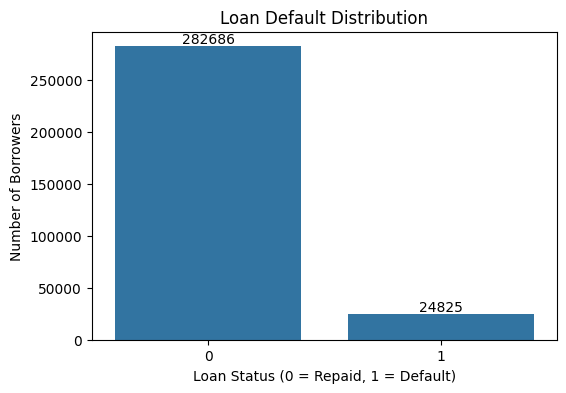

In [20]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='TARGET', data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = Repaid, 1 = Default)")
plt.ylabel("Number of Borrowers")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.show()

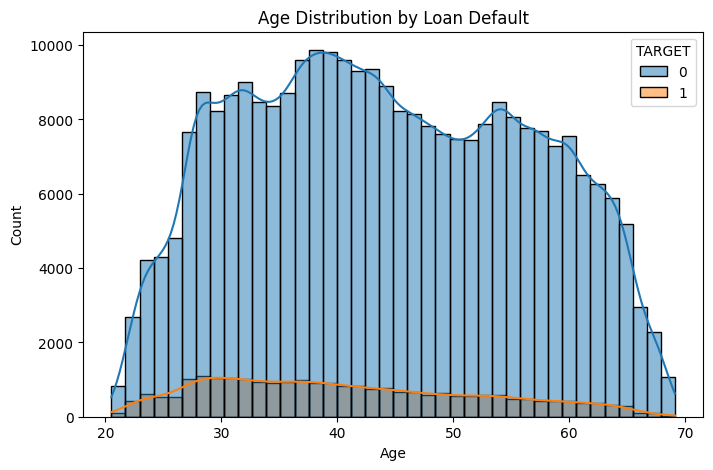

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='AGE_YEARS', hue='TARGET', bins=40, kde=True)
plt.title("Age Distribution by Loan Default")
plt.xlabel("Age")
plt.show()

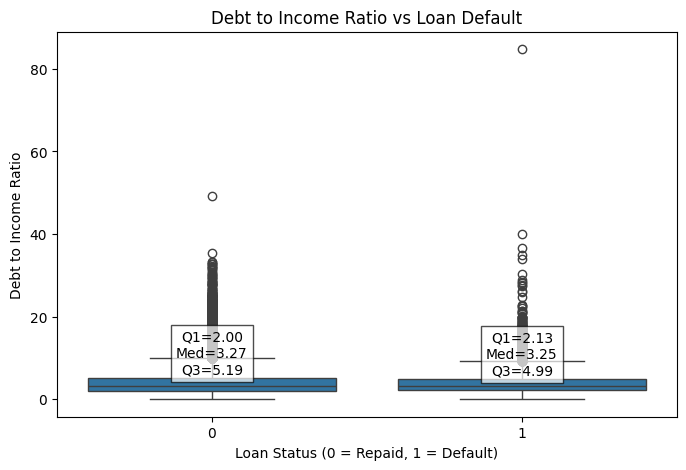

In [29]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x='TARGET', y='DTI', data=df)

plt.title("Debt to Income Ratio vs Loan Default")
plt.xlabel("Loan Status (0 = Repaid, 1 = Default)")
plt.ylabel("Debt to Income Ratio")

grouped = df.groupby('TARGET')['DTI']
q1 = grouped.quantile(0.25)
median = grouped.quantile(0.5)
q3 = grouped.quantile(0.75)

for i in range(len(q1)):
    text = f"Q1={q1[i]:.2f}\nMed={median[i]:.2f}\nQ3={q3[i]:.2f}"
    ax.text(i, q3[i] + 1, text, ha='center', fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

plt.show()

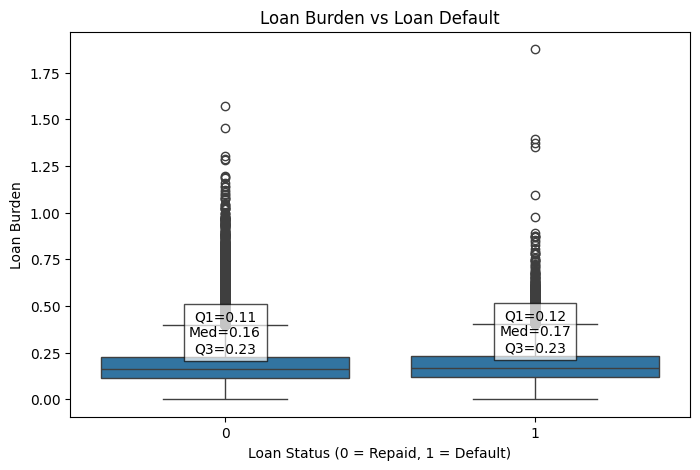

In [34]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x='TARGET', y='LOAN_BURDEN', data=df)

plt.title("Loan Burden vs Loan Default")
plt.xlabel("Loan Status (0 = Repaid, 1 = Default)")
plt.ylabel("Loan Burden")

grouped = df.groupby('TARGET')['LOAN_BURDEN']
q1 = grouped.quantile(0.25)
median = grouped.quantile(0.5)
q3 = grouped.quantile(0.75)

for i in range(len(q1)):
    text = f"Q1={q1[i]:.2f}\nMed={median[i]:.2f}\nQ3={q3[i]:.2f}"
    ax.text(i, q3[i] + 0.02, text,
            ha='center',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

plt.show()

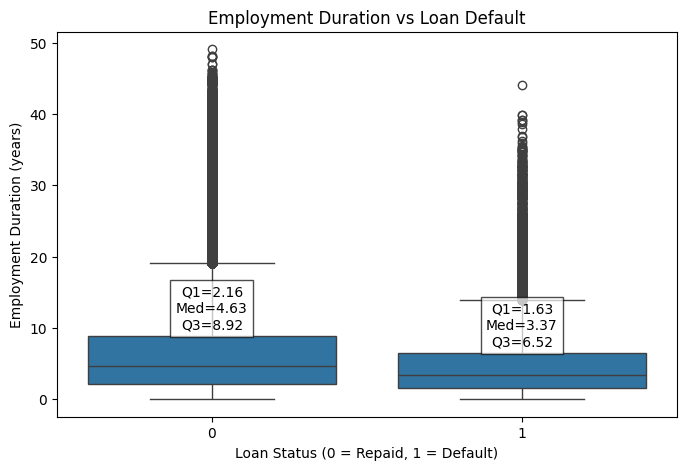

In [31]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x='TARGET', y='EMPLOYMENT_YEARS', data=df)

plt.title("Employment Duration vs Loan Default")
plt.xlabel("Loan Status (0 = Repaid, 1 = Default)")
plt.ylabel("Employment Duration (years)")

grouped = df.groupby('TARGET')['EMPLOYMENT_YEARS']
q1 = grouped.quantile(0.25)
median = grouped.quantile(0.5)
q3 = grouped.quantile(0.75)

for i in range(len(q1)):
    text = f"Q1={q1[i]:.2f}\nMed={median[i]:.2f}\nQ3={q3[i]:.2f}"
    ax.text(i, q3[i] + 1, text,
            ha='center',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

plt.show()

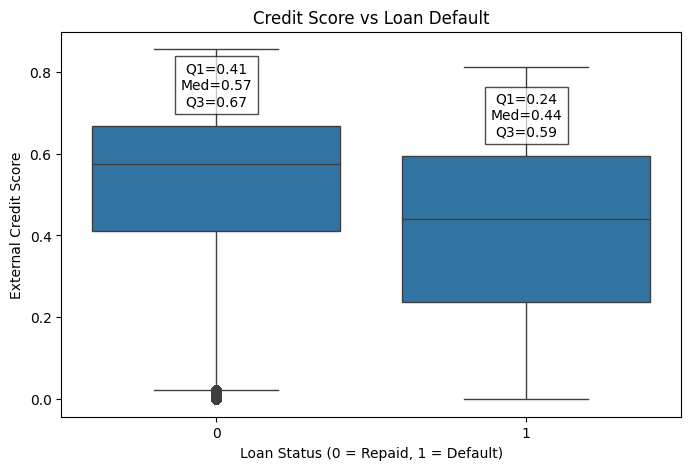

In [35]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x='TARGET', y='EXT_SOURCE_2', data=df)

plt.title("Credit Score vs Loan Default")
plt.xlabel("Loan Status (0 = Repaid, 1 = Default)")
plt.ylabel("External Credit Score")

grouped = df.groupby('TARGET')['EXT_SOURCE_2']
q1 = grouped.quantile(0.25)
median = grouped.quantile(0.5)
q3 = grouped.quantile(0.75)

for i in range(len(q1)):
    text = f"Q1={q1[i]:.2f}\nMed={median[i]:.2f}\nQ3={q3[i]:.2f}"
    ax.text(i, q3[i] + 0.05, text,
            ha='center',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.7))

plt.show()

Logistic Regression Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.14      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.53      0.50      0.48     61503
weighted avg       0.86      0.92      0.88     61503



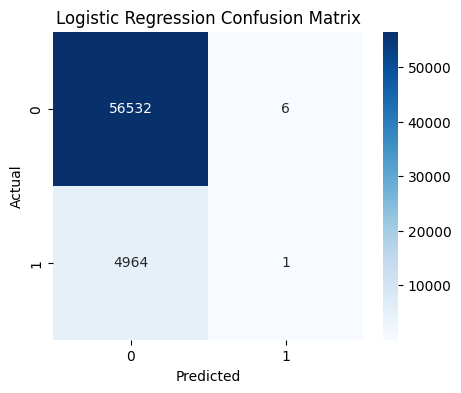

Logistic Regression ROC-AUC: 0.7129000851658307

Random Forest Report

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       1.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.96      0.50      0.48     61503
weighted avg       0.93      0.92      0.88     61503

Random Forest ROC-AUC: 0.7378738544675654


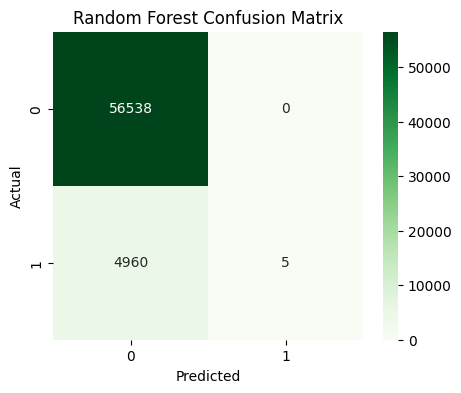

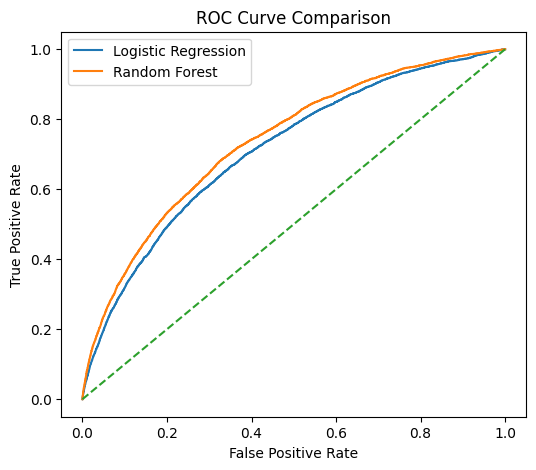


Top 10 Important Features:

EXT_SOURCE_2        0.241329
EXT_SOURCE_3        0.240141
EXT_SOURCE_1        0.097338
EMPLOYMENT_YEARS    0.070181
AGE_YEARS           0.061909
AMT_GOODS_PRICE     0.042899
AMT_CREDIT          0.042115
AMT_ANNUITY         0.041900
LOAN_BURDEN         0.040206
DTI                 0.038118
dtype: float64


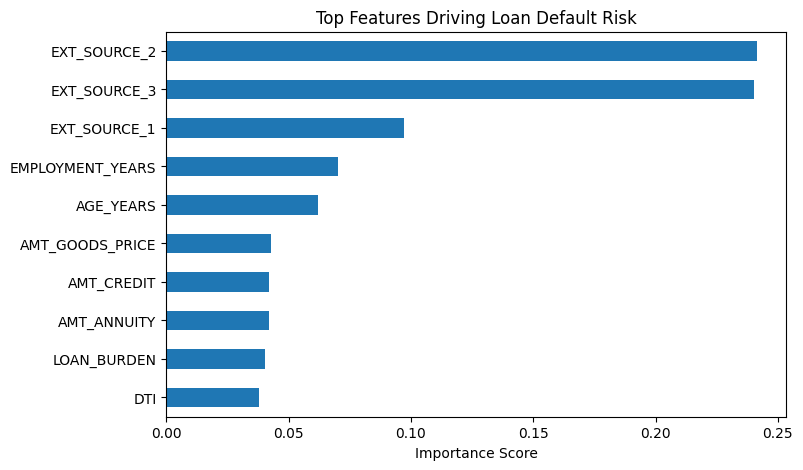

/tmp/ipykernel_55/2775051619.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_curve = df.groupby('DTI_BUCKET')['TARGET'].mean()


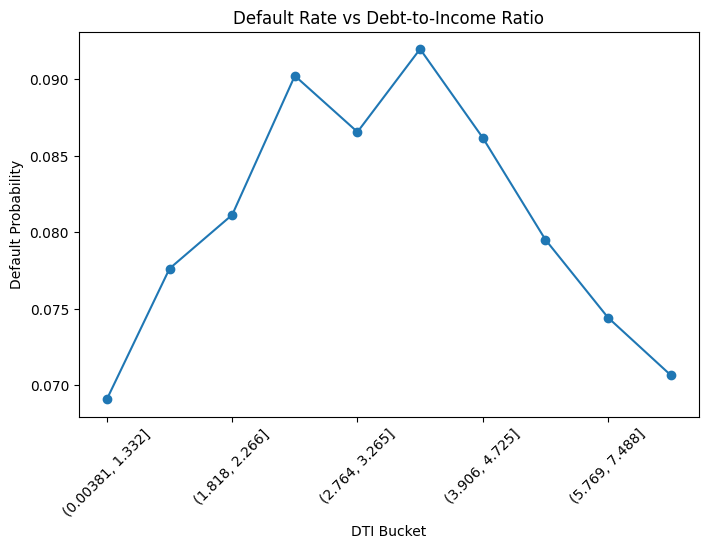

In [38]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

X = df.drop('TARGET', axis=1)
y = df['TARGET']

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print("Logistic Regression Report\n")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


auc = roc_auc_score(y_test, y_prob)
print("Logistic Regression ROC-AUC:", auc)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]


print("\nRandom Forest Report\n")
print(classification_report(y_test, y_pred_rf))


auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", auc_rf)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

feature_names = df.drop('TARGET', axis=1).columns

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)


print("\nTop 10 Important Features:\n")
print(feature_importance.head(10))


plt.figure(figsize=(8,5))

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title("Top Features Driving Loan Default Risk")
plt.xlabel("Importance Score")
plt.show()

df['DTI_BUCKET'] = pd.qcut(df['DTI'], 10)
risk_curve = df.groupby('DTI_BUCKET')['TARGET'].mean()
plt.figure(figsize=(8,5))
risk_curve.plot(marker='o')
plt.title("Default Rate vs Debt-to-Income Ratio")
plt.ylabel("Default Probability")
plt.xlabel("DTI Bucket")
plt.xticks(rotation=45)
plt.show()

In [41]:
df.to_csv("loan_analysis_ds.csv", index=False, na_rep='NULL')

In [43]:
import sqlite3

df['DTI_BUCKET'] = df['DTI_BUCKET'].astype(str)

conn = sqlite3.connect("loan_database.db")

df.to_sql("loan_data", conn, if_exists="replace", index=False)

print("Database created successfully")

Database created successfully


In [44]:
import pandas as pd

query = "SELECT * FROM loan_data LIMIT 5"

pd.read_sql(query, conn)

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_FAM_MEMBERS,REGION_POPULATION_RELATIVE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,DTI,LOAN_BURDEN,AGE_YEARS,EMPLOYMENT_YEARS,DTI_BUCKET
0,1,0,202500.0,406597.5,24700.5,351000.0,1.0,0.018801,0.083037,0.262949,0.139376,1.0,2.007889,0.121978,25.920548,1.745205,"(1.818, 2.266]"
1,0,0,270000.0,1293502.5,35698.5,1129500.0,2.0,0.003541,0.311267,0.622246,NaN,0.0,4.790750,0.132217,45.931507,3.254795,"(4.725, 5.769]"
2,0,0,67500.0,135000.0,6750.0,135000.0,1.0,0.010032,NaN,0.555912,0.729567,0.0,2.000000,0.100000,52.180822,0.616438,"(1.818, 2.266]"
3,0,0,135000.0,312682.5,29686.5,297000.0,2.0,0.008019,NaN,0.650442,NaN,NaN,2.316167,0.219900,52.068493,8.326027,"(2.266, 2.764]"
4,0,0,121500.0,513000.0,21865.5,513000.0,1.0,0.028663,NaN,0.322738,NaN,0.0,4.222222,0.179963,54.608219,8.323288,"(3.906, 4.725]"


In [45]:
query = """
SELECT
COUNT(*) AS total_loans,
SUM(TARGET) AS total_defaults,
ROUND(AVG(TARGET)*100,2) AS default_rate_percent
FROM loan_data
"""

pd.read_sql(query, conn)

,total_loans,total_defaults,default_rate_percent
0,307511,24825,8.07


In [46]:
query = """
SELECT
TARGET,
ROUND(AVG(DTI),2) AS avg_dti,
ROUND(AVG(LOAN_BURDEN),2) AS avg_loan_burden
FROM loan_data
GROUP BY TARGET
"""

pd.read_sql(query, conn)

,TARGET,avg_dti,avg_loan_burden
0,0,3.96,0.18
1,1,3.89,0.19


In [47]:
query = """
SELECT
TARGET,
ROUND(AVG(EMPLOYMENT_YEARS),2) AS avg_employment_years
FROM loan_data
GROUP BY TARGET
"""

pd.read_sql(query, conn)

,TARGET,avg_employment_years
0,0,6.68
1,1,4.97


In [48]:
query = """
SELECT
TARGET,
ROUND(AVG(EXT_SOURCE_2),3) AS avg_credit_score
FROM loan_data
GROUP BY TARGET
"""

pd.read_sql(query, conn)

,TARGET,avg_credit_score
0,0,0.523
1,1,0.411


In [49]:
query = """
SELECT *
FROM loan_data
WHERE DTI > 4
AND LOAN_BURDEN > 0.3
LIMIT 10
"""

pd.read_sql(query, conn)

,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,CNT_FAM_MEMBERS,REGION_POPULATION_RELATIVE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_REQ_CREDIT_BUREAU_YEAR,DTI,LOAN_BURDEN,AGE_YEARS,EMPLOYMENT_YEARS,DTI_BUCKET
0,0,0,112500.0,1019610.0,33826.5,913500.0,2.0,0.018634,0.587334,0.205747,0.751724,1.0,9.063200,0.300680,55.065753,NaN,"(7.488, 84.737]"
1,0,0,108000.0,746280.0,42970.5,675000.0,1.0,0.010966,NaN,0.766138,0.684828,3.0,6.910000,0.397875,64.515068,NaN,"(5.769, 7.488]"
2,0,0,81000.0,675000.0,32472.0,675000.0,2.0,0.010006,NaN,0.662865,0.738020,2.0,8.333333,0.400889,50.989041,NaN,"(7.488, 84.737]"
3,0,0,180000.0,1663987.5,86989.5,1588500.0,2.0,0.018801,NaN,0.570666,0.697147,1.0,9.244375,0.483275,55.126027,6.701370,"(7.488, 84.737]"
4,0,0,90000.0,547344.0,30690.0,472500.0,2.0,0.022625,0.763137,0.644627,NaN,1.0,6.081600,0.341000,50.838356,2.361644,"(5.769, 7.488]"
5,0,1,76500.0,808650.0,26217.0,675000.0,3.0,0.022800,0.405564,0.047291,0.406617,0.0,10.570588,0.342706,30.010959,6.764384,"(7.488, 84.737]"
6,0,0,202500.0,1136439.0,73611.0,1089000.0,1.0,0.032561,0.774880,0.711289,0.597192,1.0,5.612044,0.363511,64.810959,2.652055,"(4.725, 5.769]"
7,0,1,157500.0,1571931.0,49356.0,1435500.0,3.0,0.046220,NaN,0.682017,NaN,1.0,9.980514,0.313371,43.695890,0.654795,"(7.488, 84.737]"
8,0,0,180000.0,1755000.0,61132.5,1755000.0,2.0,0.014520,0.867872,0.147685,0.669057,2.0,9.750000,0.339625,44.071233,4.243836,"(7.488, 84.737]"
9,0,1,81000.0,532494.0,30699.0,454500.0,3.0,0.009334,NaN,0.171535,0.540654,0.0,6.574000,0.379000,53.493151,NaN,"(5.769, 7.488]"


In [50]:
df.to_csv("loan_analysis_dt.csv", index=False)